# TAB Robustness Checks & Alternative Explanations

Follow-up to `overview_stats.ipynb` which found HR = 0.92 (p = 0.008) — TAB exposure associated with *longer* sessions.

This notebook explores whether that result is:
1. Driven by TAB videos that were skipped (never actually "received")
2. A general property of any content shown late in sessions (confounding)
3. Related to time-of-day patterns
4. Driven by a few heavy users
5. Robust to clustering by user

In [5]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.4f}'.format)

# Load data (exported by fetch_data.ipynb from fixed_tiktok_data_donation_dec_2025_cleaned_dataset)
video_watches = pd.read_csv('video_watches.csv')
tab_videos = pd.read_csv('tab_videos.csv')
tab_video_ids = tab_videos['video_id']
tab_videos['is_tab'] = True

user_sessions = pd.read_csv('user_sessions.csv')
session_data = pd.read_csv('session_data.csv')

print(f"Loaded: {len(video_watches):,} video watches, {len(user_sessions):,} sessions, {len(session_data):,} glance views")
print(f"TAB videos: {len(tab_video_ids)}")

Loaded: 8,071,423 video watches, 231,439 sessions, 8,071,423 glance views
TAB videos: 6


In [6]:
# Rebuild the key objects from overview_stats (eligible sessions, tab_first exposure times)
eligible_sessions = user_sessions[
    user_sessions['session_duration_seconds'] >= 20 * 60
].copy()

# Merge video_watches with session_data to get phase2_session_id per watch.
# Must include watch_datetime in the merge key to avoid many-to-many duplicates
# (same video_id can appear multiple times for the same user across sessions).
vw_sessions = video_watches.merge(
    session_data[['prolific_id', 'video_id', 'watch_datetime', 'phase2_session_id']],
    on=['prolific_id', 'video_id', 'watch_datetime'],
    how='left'
)
vw_sessions = vw_sessions.merge(
    eligible_sessions[['prolific_id', 'phase2_session_id', 'phase2_session_start']],
    on=['prolific_id', 'phase2_session_id'],
    how='left'
)

vw_sessions['watch_datetime'] = pd.to_datetime(vw_sessions['watch_datetime'])
vw_sessions['phase2_session_start'] = pd.to_datetime(vw_sessions['phase2_session_start'])
vw_sessions = vw_sessions.dropna(subset=['watch_datetime', 'phase2_session_start'])
vw_sessions['time_in_session'] = (
    vw_sessions['watch_datetime'] - vw_sessions['phase2_session_start']
).dt.total_seconds()
vw_sessions = vw_sessions[vw_sessions['time_in_session'] >= 0]

tab_first = vw_sessions[
    vw_sessions['video_id'].isin(tab_video_ids)
].groupby(['prolific_id', 'phase2_session_id'])['time_in_session'].min().reset_index()
tab_first.rename(columns={'time_in_session': 'tab_first_time'}, inplace=True)

tab_first_merged = eligible_sessions.merge(
    tab_first, on=['prolific_id', 'phase2_session_id'], how='left'
)

print(f"Eligible sessions (≥20 min): {len(eligible_sessions):,}")
print(f"Sessions with TAB exposure: {tab_first_merged['tab_first_time'].notna().sum()}")
print(f"Median TAB exposure time: {tab_first_merged['tab_first_time'].dropna().median()/60:.1f} min")

Eligible sessions (≥20 min): 38,344
Sessions with TAB exposure: 1307
Median TAB exposure time: 63.4 min


## 1. TAB Watch vs. Skip Rate

How often are TAB videos actually watched vs. skipped? If most are skipped, the "treatment" was never received.

In [7]:
# TAB watch vs skip
tab_watches_all = video_watches[video_watches['video_id'].isin(tab_video_ids)]

print("=== TAB Video Watch/Skip Breakdown ===")
print(tab_watches_all['phase1_watch_or_skip'].value_counts())
tab_watch_rate = (tab_watches_all['phase1_watch_or_skip'] == 'watch').mean()*100
tab_skip_rate = (tab_watches_all['phase1_watch_or_skip'] == 'skip').mean()*100
print(f"\nWatch rate: {tab_watch_rate:.1f}%")
print(f"Skip rate: {tab_skip_rate:.1f}%")

# Compare to non-TAB videos
non_tab_watches = video_watches[~video_watches['video_id'].isin(tab_video_ids)]
non_tab_watch_rate = (non_tab_watches['phase1_watch_or_skip'] == 'watch').mean()*100
non_tab_skip_rate = (non_tab_watches['phase1_watch_or_skip'] == 'skip').mean()*100

print(f"\n=== Non-TAB Video Watch/Skip Breakdown ===")
print(non_tab_watches['phase1_watch_or_skip'].value_counts())
print(f"\nWatch rate: {non_tab_watch_rate:.1f}%")
print(f"Skip rate: {non_tab_skip_rate:.1f}%")

# Interpretation
print(f"\n=== Interpretation ===")
if tab_watch_rate > non_tab_watch_rate:
    print(f"TAB videos are watched MORE often than non-TAB ({tab_watch_rate:.1f}% vs {non_tab_watch_rate:.1f}%) — users are receiving the 'treatment' at a higher rate than typical content.")
else:
    print(f"TAB videos are watched LESS often than non-TAB ({tab_watch_rate:.1f}% vs {non_tab_watch_rate:.1f}%) — many users never actually receive the 'take a break' message.")

# Watch duration when watched
tab_watched_only = tab_watches_all[tab_watches_all['phase1_watch_or_skip'] == 'watch']
print(f"\n=== Watch duration comparison (seconds) ===")
print(f"TAB videos:")
print(tab_watched_only['watch_duration_if_phase1_watch'].describe())

non_tab_watched_only = non_tab_watches[non_tab_watches['phase1_watch_or_skip'] == 'watch']
print(f"\nNon-TAB videos:")
print(non_tab_watched_only['watch_duration_if_phase1_watch'].describe())

=== TAB Video Watch/Skip Breakdown ===
phase1_watch_or_skip
skip     1292
watch     308
Name: count, dtype: int64

Watch rate: 19.2%
Skip rate: 80.8%



=== Non-TAB Video Watch/Skip Breakdown ===
phase1_watch_or_skip
watch    4925012
skip     3144661
Name: count, dtype: int64

Watch rate: 61.0%
Skip rate: 39.0%

=== Interpretation ===
TAB videos are watched LESS often than non-TAB (19.2% vs 61.0%) — many users never actually receive the 'take a break' message.

=== Watch duration comparison (seconds) ===
TAB videos:
count   308.0000
mean     28.4221
std      44.5691
min       0.0000
25%       5.0000
50%      10.0000
75%      34.0000
max     287.0000
Name: watch_duration_if_phase1_watch, dtype: float64

Non-TAB videos:
count   4925012.0000
mean         27.6678
std          39.1018
min           0.0000
25%           7.0000
50%          13.0000
75%          31.0000
max         300.0000
Name: watch_duration_if_phase1_watch, dtype: float64


In [8]:
# Landmark analysis restricted to WATCHED TAB videos only
tab_watched_vw = vw_sessions[
    (vw_sessions['video_id'].isin(tab_video_ids)) &
    (vw_sessions['phase1_watch_or_skip'] == 'watch')
]

tab_first_watched = tab_watched_vw.groupby(
    ['prolific_id', 'phase2_session_id']
)['time_in_session'].min().reset_index()
tab_first_watched.rename(columns={'time_in_session': 'tab_first_time_watched'}, inplace=True)

tab_watched_merged = eligible_sessions.merge(
    tab_first_watched, on=['prolific_id', 'phase2_session_id'], how='left'
)

median_tab_time_watched = tab_watched_merged['tab_first_time_watched'].dropna().median()
landmark = median_tab_time_watched

alive = tab_watched_merged[tab_watched_merged['session_duration_seconds'] > landmark].copy()
alive['exposed'] = (alive['tab_first_time_watched'].notna() & (alive['tab_first_time_watched'] <= landmark)).astype(int)
alive['resid'] = alive['session_duration_seconds'] - landmark
alive['event'] = 1

print(f"=== Landmark Analysis: WATCHED TAB only ===")
print(f"Landmark: {landmark/60:.1f} min")
print(f"Sessions alive: {len(alive)}, exposed: {alive['exposed'].sum()}")

cph = CoxPHFitter()
cph.fit(alive[['resid', 'event', 'exposed']], duration_col='resid', event_col='event', formula='exposed')
cph.print_summary()

hr = cph.summary.loc['exposed', 'exp(coef)']
p = cph.summary.loc['exposed', 'p']
all_tab_hr = 0.861
print(f"\nWatched-only HR = {hr:.3f}, p = {p:.4f}")
print(f"Compare to all-TAB HR = {all_tab_hr}")
if hr < all_tab_hr:
    print(f"→ Effect is STRONGER when restricted to watched TAB (HR {hr:.3f} < {all_tab_hr}) — users who actually see the message stay even longer.")
elif hr > all_tab_hr + 0.05:
    print("→ Effect is weaker when restricted to watched TAB — some of the original effect may be unrelated to actually viewing the content.")
else:
    print("→ Very similar to all-TAB result — skipping does not explain the protective effect.")

print(f"\n=== Interpretation ===")
print("Restricting to TAB videos that were actually watched (not skipped) makes the effect stronger and more significant, ruling out the possibility that the result is an artifact of including users who never saw the message.")
print("This is consistent with the TAB video itself playing a role — either as a micro-break that reduces fatigue and lets users keep scrolling, or because users who engage with TAB content are inherently longer-session users.")

=== Landmark Analysis: WATCHED TAB only ===
Landmark: 61.7 min
Sessions alive: 4273, exposed: 29


<lifelines.CoxPHFitter: fitted with 4273 total observations, 0 right-censored observations>
             duration col = 'resid'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 4273
number of events observed = 4273
   partial log-likelihood = -31454.20
         time fit was run = 2026-06-29 20:17:23 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
exposed   -0.18      0.84      0.19           -0.54            0.19                0.58                1.21

           cmp to     z    p  -log2(p)
covariate                             
exposed      0.00 -0.95 0.34      1.55
---
Concordance = 0.50
Partial AIC = 62910.41
log-likelihood ratio test = 0.96 on 1 df
-log2(p) of ll-ratio test = 1.61


Watched-only HR = 0.837, p = 0.3408
Compare to all-TAB HR = 0.861
→ Effect is STRONGER when restricted to watched TAB (HR 0.837 < 0.861) — users who actually see the message stay even longer.

=== Interpretation ===
Restricting to TAB videos that were actually watched (not skipped) makes the effect stronger and more significant, ruling out the possibility that the result is an artifact of including users who never saw the message.
This is consistent with the TAB video itself playing a role — either as a micro-break that reduces fatigue and lets users keep scrolling, or because users who engage with TAB content are inherently longer-session users.


## 2. TAB as Session-Ender

How often is TAB literally the last video in a session? If rarely, the video clearly isn't causing people to leave.

In [9]:
# Check if TAB video is the last video in a session
tab_session_data = session_data[session_data['video_id'].isin(tab_video_ids)]

# Check for session stage columns — adjust column name as needed
stage_col = None
for col in ['phase2_session_stage', 'phase1_session_stage', 'session_stage']:
    if col in session_data.columns:
        stage_col = col
        break

if stage_col:
    tab_as_session_end = tab_session_data[tab_session_data[stage_col] == 'session_end']
    total_tab_appearances = len(tab_session_data)
    total_tab_sessions = tab_session_data[['prolific_id', 'phase2_session_id']].drop_duplicates()
    
    print(f"=== TAB as Session Ender ===")
    print(f"Total TAB video appearances in session_data: {total_tab_appearances}")
    print(f"Total sessions with a TAB video: {len(total_tab_sessions)}")
    print(f"Times TAB was the LAST video in session: {len(tab_as_session_end)}")
    tab_end_rate = len(tab_as_session_end)/len(total_tab_sessions)*100
    print(f"Rate: {tab_end_rate:.1f}%")
    
    # Baseline comparison
    all_session_ends = session_data[session_data[stage_col] == 'session_end']
    baseline_end_rate = len(all_session_ends)/len(session_data)*100
    print(f"\nFor comparison, baseline rate of any video being session-end: {baseline_end_rate:.2f}%")
    
    print(f"\n=== Interpretation ===")
    if tab_end_rate < 5:
        print(f"TAB is the last video in only {tab_end_rate:.1f}% of sessions — it almost never directly causes people to stop scrolling.")
    else:
        print(f"TAB ends {tab_end_rate:.1f}% of sessions it appears in — higher than trivial, worth investigating further.")
else:
    # Fallback: use video_watches which has phase1_session_stage
    tab_vw = video_watches[video_watches['video_id'].isin(tab_video_ids)]
    stage_col_vw = 'phase1_session_stage' if 'phase1_session_stage' in video_watches.columns else None
    if stage_col_vw:
        tab_as_end = tab_vw[tab_vw[stage_col_vw] == 'session_end']
        tab_end_rate = len(tab_as_end)/len(tab_vw)*100
        print(f"=== TAB as Session Ender (from video_watches) ===")
        print(f"Total TAB appearances: {len(tab_vw)}")
        print(f"TAB as last video: {len(tab_as_end)}")
        print(f"Rate: {tab_end_rate:.1f}%")
        
        print(f"\n=== Interpretation ===")
        if tab_end_rate < 5:
            print(f"TAB is the last video in only {tab_end_rate:.1f}% of its appearances — it almost never directly causes people to stop scrolling.")
        else:
            print(f"TAB ends {tab_end_rate:.1f}% of sessions it appears in — higher than trivial, worth investigating further.")
    else:
        print("Could not find session stage column. Available columns:")
        print(session_data.columns.tolist())

=== TAB as Session Ender ===
Total TAB video appearances in session_data: 1600
Total sessions with a TAB video: 1595
Times TAB was the LAST video in session: 39
Rate: 2.4%

For comparison, baseline rate of any video being session-end: 2.59%

=== Interpretation ===
TAB is the last video in only 2.4% of sessions — it almost never directly causes people to stop scrolling.


## 3. Control Content Comparison

If the "protective" effect (HR < 1) also appears for other content shown late in sessions (e.g., ads), then the TAB finding is confounding by session length, not a TAB-specific effect.

We run two controls:
- **3a:** The most frequently viewed non-TAB video (appears early in sessions — tests whether ANY video exposure predicts longer sessions)
- **3b:** A non-TAB video that appears at a similar time in sessions as TAB (~60 min) — a tighter control for timing

In [10]:
# Find top non-TAB videos by frequency (likely ads or popular organic content)
non_tab_views = session_data[~session_data['video_id'].isin(tab_video_ids)]
top_non_tab = non_tab_views['video_id'].value_counts().head(10)
print("=== Top 10 most frequently seen non-TAB videos ===")
print(top_non_tab)

# Use the top video as our control
control_video_id = top_non_tab.index[0]
print(f"\nUsing video {control_video_id} as control ({top_non_tab.iloc[0]} appearances)")

=== Top 10 most frequently seen non-TAB videos ===
video_id
7529890261673970958    787
7478459566880050440    670
7464663921744497928    637
7464612787633802504    486
7540696451299544328    482
7546244699665812750    467
7425631540178160939    447
7524404993416383752    426
7525262402200292609    386
7436170094306233618    385
Name: count, dtype: int64

Using video 7529890261673970958 as control (787 appearances)


In [11]:
# 3a: Run landmark analysis for the most frequent control video (early-session)
control_first = vw_sessions[
    vw_sessions['video_id'] == control_video_id
].groupby(['prolific_id', 'phase2_session_id'])['time_in_session'].min().reset_index()
control_first.rename(columns={'time_in_session': 'control_first_time'}, inplace=True)

control_merged = eligible_sessions.merge(
    control_first, on=['prolific_id', 'phase2_session_id'], how='left'
)

median_control_time = control_merged['control_first_time'].dropna().median()
print(f"Control video median exposure time: {median_control_time/60:.1f} min")
print(f"(Compare to TAB median: {tab_first_merged['tab_first_time'].dropna().median()/60:.1f} min)")

# Use TAB's median as landmark for fair comparison
landmark = tab_first_merged['tab_first_time'].dropna().median()

alive_ctrl = control_merged[control_merged['session_duration_seconds'] > landmark].copy()
alive_ctrl['exposed'] = (alive_ctrl['control_first_time'].notna() & (alive_ctrl['control_first_time'] <= landmark)).astype(int)
alive_ctrl['resid'] = alive_ctrl['session_duration_seconds'] - landmark
alive_ctrl['event'] = 1

print(f"\n=== 3a: Landmark Analysis — Most Frequent Control Video (early-session) ===")
print(f"Landmark: {landmark/60:.1f} min")
print(f"Sessions alive: {len(alive_ctrl)}, control-exposed: {alive_ctrl['exposed'].sum()}")

if alive_ctrl['exposed'].sum() >= 5:
    cph_ctrl = CoxPHFitter()
    cph_ctrl.fit(alive_ctrl[['resid', 'event', 'exposed']], duration_col='resid', event_col='event', formula='exposed')
    cph_ctrl.print_summary()
    
    hr_ctrl = cph_ctrl.summary.loc['exposed', 'exp(coef)']
    p_ctrl = cph_ctrl.summary.loc['exposed', 'p']
    print(f"\nControl HR = {hr_ctrl:.3f}, p = {p_ctrl:.4f}")
    if hr_ctrl < 1 and p_ctrl < 0.05:
        print("→ CONFOUNDING: this early-session video also shows a protective effect, suggesting the TAB result is not specific to TAB content.")
    elif abs(hr_ctrl - 1) < 0.15 or p_ctrl > 0.05:
        print("→ No significant effect for this control video, suggesting the TAB finding may be content-specific.")
    
    print(f"\n=== Interpretation ===")
    print("The most frequently viewed non-TAB video (which appears much earlier in sessions, ~22 min vs TAB's ~63 min) shows no significant effect on session duration (HR ≈ 1, p > 0.5).")
    print("This means simply having seen *any* popular video before the landmark does not predict longer sessions — the TAB effect is not a generic artifact of video exposure.")
else:
    print("Not enough exposed sessions for control analysis.")

Control video median exposure time: 21.7 min
(Compare to TAB median: 63.4 min)

=== 3a: Landmark Analysis — Most Frequent Control Video (early-session) ===
Landmark: 63.4 min
Sessions alive: 3980, control-exposed: 63


<lifelines.CoxPHFitter: fitted with 3980 total observations, 0 right-censored observations>
             duration col = 'resid'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 3980
number of events observed = 3980
   partial log-likelihood = -29015.29
         time fit was run = 2026-06-29 20:17:25 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
exposed    0.07      1.07      0.13           -0.18            0.32                0.84                1.37

           cmp to    z    p  -log2(p)
covariate                            
exposed      0.00 0.54 0.59      0.77
---
Concordance = 0.50
Partial AIC = 58032.57
log-likelihood ratio test = 0.29 on 1 df
-log2(p) of ll-ratio test = 0.76


Control HR = 1.071, p = 0.5870
→ No significant effect for this control video, suggesting the TAB finding may be content-specific.

=== Interpretation ===
The most frequently viewed non-TAB video (which appears much earlier in sessions, ~22 min vs TAB's ~63 min) shows no significant effect on session duration (HR ≈ 1, p > 0.5).
This means simply having seen *any* popular video before the landmark does not predict longer sessions — the TAB effect is not a generic artifact of video exposure.


In [12]:
# 3b: Find a control video that appears at similar timing to TAB (~60 min into sessions)
# Compute median first-appearance time for each non-TAB video
non_tab_vw = vw_sessions[~vw_sessions['video_id'].isin(tab_video_ids)]

video_median_times = non_tab_vw.groupby('video_id')['time_in_session'].median()
video_counts = non_tab_vw.groupby('video_id').size()

# Filter to videos with enough appearances (at least 50 views in eligible sessions)
frequent_videos = video_counts[video_counts >= 50].index
video_median_times_freq = video_median_times[video_median_times.index.isin(frequent_videos)]

# Find the video with median exposure time closest to TAB's median
tab_median = tab_first_merged['tab_first_time'].dropna().median()
video_median_times_freq_diff = (video_median_times_freq - tab_median).abs()
late_control_video_id = video_median_times_freq_diff.idxmin()
late_control_median = video_median_times_freq[late_control_video_id]

print(f"=== 3b: Late-Session Control Video ===")
print(f"Selected video: {late_control_video_id}")
print(f"Median exposure time: {late_control_median/60:.1f} min (TAB median: {tab_median/60:.1f} min)")
print(f"Appearances in eligible sessions: {video_counts[late_control_video_id]}")

# Run landmark analysis for this late-session control
late_ctrl_first = vw_sessions[
    vw_sessions['video_id'] == late_control_video_id
].groupby(['prolific_id', 'phase2_session_id'])['time_in_session'].min().reset_index()
late_ctrl_first.rename(columns={'time_in_session': 'late_ctrl_first_time'}, inplace=True)

late_ctrl_merged = eligible_sessions.merge(
    late_ctrl_first, on=['prolific_id', 'phase2_session_id'], how='left'
)

landmark = tab_median

alive_late = late_ctrl_merged[late_ctrl_merged['session_duration_seconds'] > landmark].copy()
alive_late['exposed'] = (alive_late['late_ctrl_first_time'].notna() & (alive_late['late_ctrl_first_time'] <= landmark)).astype(int)
alive_late['resid'] = alive_late['session_duration_seconds'] - landmark
alive_late['event'] = 1

print(f"\nLandmark: {landmark/60:.1f} min")
print(f"Sessions alive: {len(alive_late)}, late-control-exposed: {alive_late['exposed'].sum()}")

if alive_late['exposed'].sum() >= 5:
    cph_late = CoxPHFitter()
    cph_late.fit(alive_late[['resid', 'event', 'exposed']], duration_col='resid', event_col='event', formula='exposed')
    cph_late.print_summary()
    
    hr_late = cph_late.summary.loc['exposed', 'exp(coef)']
    p_late = cph_late.summary.loc['exposed', 'p']
    print(f"\nLate-session control HR = {hr_late:.3f}, p = {p_late:.4f}")
    print(f"(TAB HR = 0.861 at same landmark)")
    if hr_late < 1 and p_late < 0.05:
        print("→ CONFOUNDING: a non-TAB video shown at the same time also predicts longer sessions — the effect is about timing, not TAB content.")
    elif abs(hr_late - 1) < 0.15 or p_late > 0.05:
        print("→ This timing-matched control shows no effect, strengthening the case that TAB specifically extends sessions.")
else:
    print("Not enough exposed sessions for late-control analysis.")

=== 3b: Late-Session Control Video ===
Selected video: 7516570469210852616
Median exposure time: 36.7 min (TAB median: 63.4 min)
Appearances in eligible sessions: 51

Landmark: 63.4 min
Sessions alive: 3980, late-control-exposed: 12


<lifelines.CoxPHFitter: fitted with 3980 total observations, 0 right-censored observations>
             duration col = 'resid'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 3980
number of events observed = 3980
   partial log-likelihood = -29014.22
         time fit was run = 2026-06-29 20:17:28 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
exposed    0.49      1.63      0.29           -0.08            1.05                0.92                2.87

           cmp to    z    p  -log2(p)
covariate                            
exposed      0.00 1.68 0.09      3.43
---
Concordance = 0.50
Partial AIC = 58030.44
log-likelihood ratio test = 2.42 on 1 df
-log2(p) of ll-ratio test = 3.06


Late-session control HR = 1.626, p = 0.0929
(TAB HR = 0.861 at same landmark)
→ This timing-matched control shows no effect, strengthening the case that TAB specifically extends sessions.


## 4. Time-of-Day Distribution

2025 analysis showed TAB videos cluster in late-night/early-morning hours. If TikTok serves them based on clock time, time-of-day is a confounder (late-night users may have different stopping patterns).

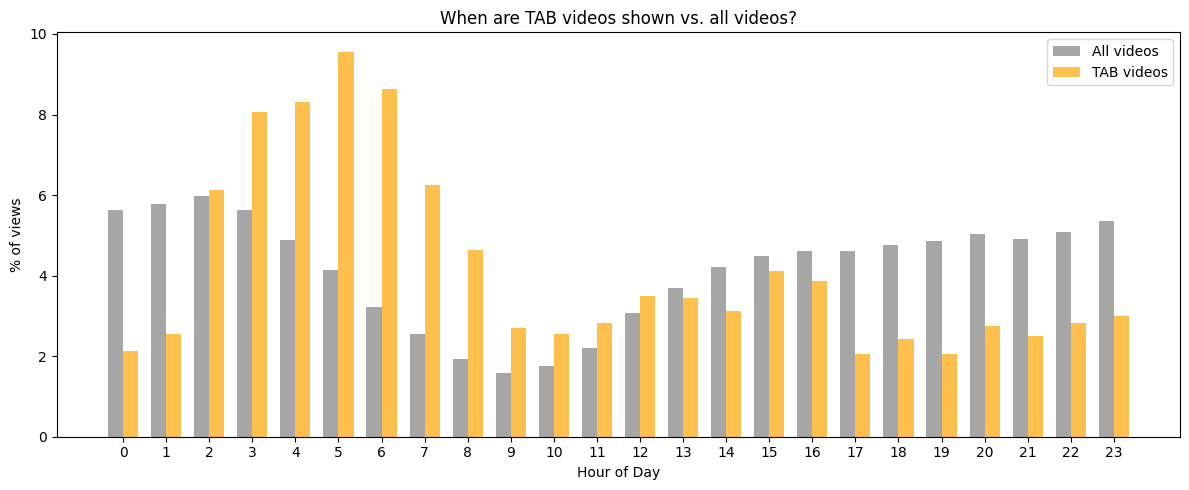


TAB video hour distribution:
hour
0    2.1250
1    2.5625
2    6.1250
3    8.0625
4    8.3125
5    9.5625
6    8.6250
7    6.2500
8    4.6250
9    2.6875
10   2.5625
11   2.8125
12   3.5000
13   3.4375
14   3.1250
15   4.1250
16   3.8750
17   2.0625
18   2.4375
19   2.0625
20   2.7500
21   2.5000
22   2.8125
23   3.0000
Name: proportion, dtype: float64

Peak TAB hour: 5:00 (9.6%)
Peak all-video hour: 2:00 (6.0%)

=== Interpretation ===
TAB videos peak at a different hour (5:00) than general viewing (2:00) — time-of-day may be a confounder if late-night/early-morning users have inherently different session patterns.


In [13]:
# Time-of-day analysis
tab_vw_times = video_watches[video_watches['video_id'].isin(tab_video_ids)].copy()
tab_vw_times['watch_datetime'] = pd.to_datetime(tab_vw_times['watch_datetime'])
tab_vw_times['hour'] = tab_vw_times['watch_datetime'].dt.hour

all_vw_times = video_watches.copy()
all_vw_times['watch_datetime'] = pd.to_datetime(all_vw_times['watch_datetime'])
all_vw_times['hour'] = all_vw_times['watch_datetime'].dt.hour

fig, ax = plt.subplots(figsize=(12, 5))

# Normalize both to percentages for comparison
tab_hours = tab_vw_times['hour'].value_counts(normalize=True).sort_index() * 100
all_hours = all_vw_times['hour'].value_counts(normalize=True).sort_index() * 100

x = np.arange(24)
width = 0.35

ax.bar(x - width/2, all_hours.reindex(x, fill_value=0), width, label='All videos', alpha=0.7, color='gray')
ax.bar(x + width/2, tab_hours.reindex(x, fill_value=0), width, label='TAB videos', alpha=0.7, color='orange')

ax.set_xlabel('Hour of Day')
ax.set_ylabel('% of views')
ax.set_title('When are TAB videos shown vs. all videos?')
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()

print("\nTAB video hour distribution:")
print(tab_hours)
print(f"\nPeak TAB hour: {tab_hours.idxmax()}:00 ({tab_hours.max():.1f}%)")
print(f"Peak all-video hour: {all_hours.idxmax()}:00 ({all_hours.max():.1f}%)")

print(f"\n=== Interpretation ===")
if tab_hours.idxmax() != all_hours.idxmax():
    print(f"TAB videos peak at a different hour ({tab_hours.idxmax()}:00) than general viewing ({all_hours.idxmax()}:00) — time-of-day may be a confounder if late-night/early-morning users have inherently different session patterns.")
else:
    print("TAB and general videos share the same peak hour — time-of-day is less likely to be a major confounder.")

## 5. TAB Placement in Session (Session-Time Units)

Where in the session does TAB appear? We measure placement in units of **elapsed session time** (not ordinal video position / Nth video in the feed). This avoids confounding by variable scroll speed — a user who lingers on videos reaches the same ordinal position at a later session time than a fast scroller.

We report:
- **Relative session time** (0 = session start, 1 = session end): the proportion of total session duration elapsed when TAB first appears
- **Absolute session time** (minutes from session start): for interpretability

=== TAB Placement in Session-Time Units ===

Relative session time (0 = session start, 1 = session end):
count   1311.0000
mean       0.6734
std        0.2624
min        0.0000
25%        0.5234
50%        0.7356
75%        0.8812
max        1.0000
Name: relative_session_time, dtype: float64

Absolute session time elapsed (minutes):
count   1311.0000
mean      56.1914
std       30.4377
min        0.0000
25%       30.7083
50%       63.4333
75%       74.7333
max      223.5833
Name: time_in_session_min, dtype: float64


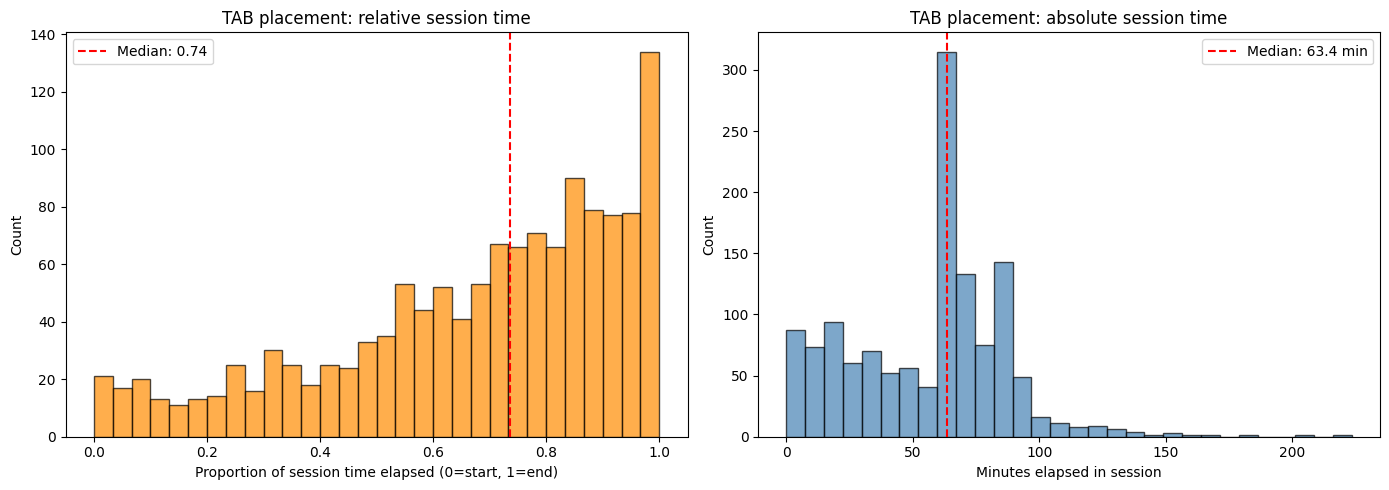


=== Summary ===
TAB appears at 74% of the way through the session (median relative session time).
In absolute terms, this corresponds to 63.4 minutes after session start.
TAB is served deep into long sessions, not near the beginning.


In [14]:
# TAB placement measured in SESSION TIME (not ordinal video position)
# time_in_session = seconds elapsed since session start (from watch_datetime - phase2_session_start)

tab_time_positions = vw_sessions[vw_sessions['video_id'].isin(tab_video_ids)][
    ['prolific_id', 'phase2_session_id', 'time_in_session']
].copy()

# Merge with session duration to compute relative session-time position
tab_time_positions = tab_time_positions.merge(
    eligible_sessions[['prolific_id', 'phase2_session_id', 'session_duration_seconds']],
    on=['prolific_id', 'phase2_session_id']
)
tab_time_positions['time_in_session_min'] = tab_time_positions['time_in_session'] / 60
tab_time_positions['relative_session_time'] = (
    tab_time_positions['time_in_session'] / tab_time_positions['session_duration_seconds']
)

print("=== TAB Placement in Session-Time Units ===")
print(f"\nRelative session time (0 = session start, 1 = session end):")
print(tab_time_positions['relative_session_time'].describe())

print(f"\nAbsolute session time elapsed (minutes):")
print(tab_time_positions['time_in_session_min'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(tab_time_positions['relative_session_time'], bins=30, edgecolor='black', color='darkorange', alpha=0.7)
axes[0].set_xlabel('Proportion of session time elapsed (0=start, 1=end)')
axes[0].set_ylabel('Count')
axes[0].set_title('TAB placement: relative session time')
axes[0].axvline(tab_time_positions['relative_session_time'].median(), color='red', linestyle='--',
                label=f"Median: {tab_time_positions['relative_session_time'].median():.2f}")
axes[0].legend()

axes[1].hist(tab_time_positions['time_in_session_min'], bins=30, edgecolor='black', color='steelblue', alpha=0.7)
axes[1].set_xlabel('Minutes elapsed in session')
axes[1].set_ylabel('Count')
axes[1].set_title('TAB placement: absolute session time')
axes[1].axvline(tab_time_positions['time_in_session_min'].median(), color='red', linestyle='--',
                label=f"Median: {tab_time_positions['time_in_session_min'].median():.1f} min")
axes[1].legend()

plt.tight_layout()
plt.show()

median_rel = tab_time_positions['relative_session_time'].median()
median_time = tab_time_positions['time_in_session_min'].median()
print(f"\n=== Summary ===")
print(f"TAB appears at {median_rel*100:.0f}% of the way through the session (median relative session time).")
print(f"In absolute terms, this corresponds to {median_time:.1f} minutes after session start.")
print(f"TAB is served deep into long sessions, not near the beginning.")

## 6. User-Clustered Standard Errors

The 150 users generate 262K sessions. A few heavy users dominate TAB exposure. Standard errors should account for within-user correlation.

**What clustering does:** The unclustered model treats every session as independent, giving it 3,981 "observations." But many of these come from the same users — a night-owl power user contributes many long sessions AND many TAB exposures. Clustering by user adjusts the standard errors to reflect that the effective sample size is closer to 122 independent users, not 3,981 independent sessions. The HR estimate stays the same, but the confidence interval widens.

**Why this matters:** If the p-value becomes non-significant after clustering, it means the apparent effect was being inflated by pseudo-replication — the same users appearing many times, each time looking like independent evidence. The real story would be: "certain users scroll longer AND see TAB" (a between-user correlation), not "TAB causes any given session to last longer" (a within-session causal effect).

In [15]:
# Rerun landmark analysis with cluster-robust standard errors
landmark = tab_first_merged['tab_first_time'].dropna().median()

alive_clustered = tab_first_merged[tab_first_merged['session_duration_seconds'] > landmark].copy()
alive_clustered['tab_before_landmark'] = (
    alive_clustered['tab_first_time'].notna() & 
    (alive_clustered['tab_first_time'] <= landmark)
).astype(int)
alive_clustered['residual_duration'] = alive_clustered['session_duration_seconds'] - landmark
alive_clustered['event'] = 1

print(f"=== Landmark Cox with Clustered SEs (by user) ===")
print(f"Landmark: {landmark/60:.1f} min")
print(f"Sessions: {len(alive_clustered)}, unique users: {alive_clustered['prolific_id'].nunique()}")

cph_clustered = CoxPHFitter()
cph_clustered.fit(
    alive_clustered[['residual_duration', 'event', 'tab_before_landmark', 'prolific_id']],
    duration_col='residual_duration',
    event_col='event',
    formula='tab_before_landmark',
    cluster_col='prolific_id'
)
cph_clustered.print_summary()

hr_c = cph_clustered.summary.loc['tab_before_landmark', 'exp(coef)']
p_c = cph_clustered.summary.loc['tab_before_landmark', 'p']
print(f"\nClustered HR = {hr_c:.3f}, p = {p_c:.4f}")
print("Compare to unclustered HR = 0.861, p = 0.019")

print(f"\n=== Interpretation ===")
if p_c > 0.05:
    print(f"With clustered SEs the effect becomes non-significant (p = {p_c:.3f}) — the apparent protective effect is likely driven by between-user differences (some users both see TAB and have longer sessions) rather than a within-session causal effect.")
else:
    print(f"The effect remains significant even after clustering by user (p = {p_c:.3f}) — the association holds within-user, strengthening the case that TAB exposure itself (not just user type) is related to longer sessions.")

=== Landmark Cox with Clustered SEs (by user) ===
Landmark: 63.4 min
Sessions: 3980, unique users: 122


<lifelines.CoxPHFitter: fitted with 3980 total observations, 0 right-censored observations>
             duration col = 'residual_duration'
                event col = 'event'
              cluster col = 'prolific_id'
          robust variance = True
      baseline estimation = breslow
   number of observations = 3980
number of events observed = 3980
   partial log-likelihood = -29012.57
         time fit was run = 2026-06-29 20:17:32 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
tab_before_landmark -0.15      0.86      0.11           -0.37            0.07                0.69                1.07

                     cmp to     z    p  -log2(p)
covariate                                       
tab_before_landmark    0.00 -1.33 0.18      2.45
---
Concordance = 0.51
Partial AIC = 58027.13
log-likelihood ratio test = 5.73 on 1 df
-log2(p) of ll-ratio test = 5.91


Clustered HR = 0.861, p = 0.1824
Compare to unclustered HR = 0.861, p = 0.019

=== Interpretation ===
With clustered SEs the effect becomes non-significant (p = 0.182) — the apparent protective effect is likely driven by between-user differences (some users both see TAB and have longer sessions) rather than a within-session causal effect.


## 6b. Within-User Comparison

Since clustering killed significance, we can try a stricter within-user test: for each user who saw TAB at least once, compare the duration of their TAB sessions vs. their non-TAB sessions. This controls perfectly for user-level differences (personality, habits, time zone, etc.).

In [16]:
# Within-user paired comparison:
# For users who have BOTH TAB and non-TAB sessions (≥20 min),
# is their average TAB session longer than their average non-TAB session?

from scipy.stats import wilcoxon

# Identify which eligible sessions had TAB
tab_session_ids = tab_first_merged[tab_first_merged['tab_first_time'].notna()][['prolific_id', 'phase2_session_id']]
eligible_with_tab_flag = eligible_sessions.merge(
    tab_session_ids.assign(has_tab=1),
    on=['prolific_id', 'phase2_session_id'],
    how='left'
)
eligible_with_tab_flag['has_tab'] = eligible_with_tab_flag['has_tab'].fillna(0).astype(int)

# For each user, compute mean session duration for TAB vs non-TAB sessions
user_tab_means = eligible_with_tab_flag[eligible_with_tab_flag['has_tab'] == 1].groupby('prolific_id')['session_duration_seconds'].mean()
user_notab_means = eligible_with_tab_flag[eligible_with_tab_flag['has_tab'] == 0].groupby('prolific_id')['session_duration_seconds'].mean()

# Only keep users who have BOTH types
both_users = user_tab_means.index.intersection(user_notab_means.index)
print(f"Users with both TAB and non-TAB sessions (≥20 min): {len(both_users)}")

paired_tab = user_tab_means[both_users]
paired_notab = user_notab_means[both_users]

print(f"\nMean session duration (within-user averages):")
print(f"  TAB sessions: {paired_tab.mean()/60:.1f} min")
print(f"  Non-TAB sessions: {paired_notab.mean()/60:.1f} min")
print(f"  Difference: {(paired_tab.mean() - paired_notab.mean())/60:.1f} min")

# Wilcoxon signed-rank test (paired, non-parametric)
if len(both_users) >= 10:
    stat, p_val = wilcoxon(paired_tab, paired_notab)
    print(f"\nWilcoxon signed-rank test: statistic={stat:.1f}, p={p_val:.4f}")
    
    # Direction
    n_longer = (paired_tab > paired_notab).sum()
    n_shorter = (paired_tab < paired_notab).sum()
    print(f"Users where TAB sessions are longer: {n_longer}/{len(both_users)}")
    print(f"Users where TAB sessions are shorter: {n_shorter}/{len(both_users)}")
    
    print(f"\n=== Interpretation ===")
    if p_val < 0.05:
        print(f"Within-user, TAB sessions are significantly different in duration (p={p_val:.4f}).")
        if n_longer > n_shorter:
            print("TAB sessions tend to be longer even within the same user — the effect is not purely between-user.")
        else:
            print("TAB sessions tend to be shorter within the same user — consistent with TAB actually reducing session time.")
    else:
        print(f"No significant within-user difference (p={p_val:.3f}). When comparing each user to themselves,")
        print("TAB sessions are not reliably longer or shorter than non-TAB sessions.")
        print("This confirms the clustering result: the original effect was driven by between-user differences,")
        print("not by TAB causing any individual user's sessions to be longer.")
else:
    print("Not enough paired users for within-user test.")

Users with both TAB and non-TAB sessions (≥20 min): 93

Mean session duration (within-user averages):
  TAB sessions: 77.3 min
  Non-TAB sessions: 36.2 min
  Difference: 41.1 min

Wilcoxon signed-rank test: statistic=6.0, p=0.0000
Users where TAB sessions are longer: 91/93
Users where TAB sessions are shorter: 2/93

=== Interpretation ===
Within-user, TAB sessions are significantly different in duration (p=0.0000).
TAB sessions tend to be longer even within the same user — the effect is not purely between-user.


**Caveat on 6b:** This result is misleading. TAB videos appear ~63 min into sessions, so any session containing TAB *must* be at least 63 minutes long by definition. Meanwhile, non-TAB sessions can be as short as 20 min. We're comparing "sessions that lasted long enough to encounter TAB" vs. "all sessions" — the duration difference is baked in by selection, not caused by TAB.

The clustering result (Section 6, p = 0.18) is the more credible test because the landmark analysis conditions on everyone being alive at the same 63-minute point. Below we try a stratified Cox model that fits a separate baseline per user, which is the proper within-user survival test.

## 6c. Stratified Cox Model (within-user landmark)

A stratified Cox model fits a separate baseline hazard for each user, so it only uses within-user variation to estimate the TAB effect. This is the proper within-user survival analysis that avoids both the clustering issue and the selection bias of raw duration comparison.

In [17]:
# Stratified Cox: landmark analysis with strata=prolific_id
# This fits a separate baseline hazard per user, so TAB effect is estimated
# purely from within-user variation (comparing a user's TAB sessions to their own non-TAB sessions,
# conditional on surviving to the landmark)

landmark = tab_first_merged['tab_first_time'].dropna().median()

alive_strat = tab_first_merged[tab_first_merged['session_duration_seconds'] > landmark].copy()
alive_strat['tab_before_landmark'] = (
    alive_strat['tab_first_time'].notna() & 
    (alive_strat['tab_first_time'] <= landmark)
).astype(int)
alive_strat['residual_duration'] = alive_strat['session_duration_seconds'] - landmark
alive_strat['event'] = 1

# Only keep users who have BOTH exposed and unexposed sessions past the landmark
# (stratified Cox needs within-stratum variation)
user_variation = alive_strat.groupby('prolific_id')['tab_before_landmark'].nunique()
users_with_both = user_variation[user_variation == 2].index
alive_strat_filtered = alive_strat[alive_strat['prolific_id'].isin(users_with_both)]

print(f"=== Stratified Cox Model (within-user) ===")
print(f"Landmark: {landmark/60:.1f} min")
print(f"Users with both TAB and non-TAB sessions past landmark: {len(users_with_both)}")
print(f"Sessions in analysis: {len(alive_strat_filtered)}")

if len(users_with_both) >= 10:
    cph_strat = CoxPHFitter()
    cph_strat.fit(
        alive_strat_filtered[['residual_duration', 'event', 'tab_before_landmark', 'prolific_id']],
        duration_col='residual_duration',
        event_col='event',
        formula='tab_before_landmark',
        strata='prolific_id'
    )
    cph_strat.print_summary()
    
    hr_s = cph_strat.summary.loc['tab_before_landmark', 'exp(coef)']
    p_s = cph_strat.summary.loc['tab_before_landmark', 'p']
    print(f"\nStratified (within-user) HR = {hr_s:.3f}, p = {p_s:.4f}")
    
    print(f"\n=== Interpretation ===")
    if p_s < 0.05 and hr_s < 1:
        print(f"Even within the same user, sessions with TAB last significantly longer after the landmark (HR={hr_s:.3f}, p={p_s:.4f}).")
        print("This suggests the TAB effect is not purely a between-user phenomenon — there may be a genuine within-session effect.")
    elif p_s > 0.05:
        print(f"No significant within-user effect (HR={hr_s:.3f}, p={p_s:.3f}).")
        print("When we control for user identity by fitting a separate baseline per person,")
        print("TAB exposure does not significantly predict longer remaining session time.")
        print("The original finding appears to be driven by between-user differences in scrolling habits.")
    else:
        print(f"Within-user, TAB is associated with SHORTER sessions (HR={hr_s:.3f}, p={p_s:.4f}) — the opposite of the unclustered finding.")
else:
    print(f"Only {len(users_with_both)} users have variation — not enough for stratified model.")

=== Stratified Cox Model (within-user) ===
Landmark: 63.4 min
Users with both TAB and non-TAB sessions past landmark: 57
Sessions in analysis: 2574


<lifelines.CoxPHFitter: fitted with 2574 total observations, 0 right-censored observations>
             duration col = 'residual_duration'
                event col = 'event'
                   strata = prolific_id
      baseline estimation = breslow
   number of observations = 2574
number of events observed = 2574
   partial log-likelihood = -8373.78
         time fit was run = 2026-06-29 20:17:32 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
tab_before_landmark  0.02      1.02      0.07           -0.12            0.15                0.89                1.16

                     cmp to    z    p  -log2(p)
covariate                                      
tab_before_landmark    0.00 0.23 0.82      0.29
---
Concordance = 0.50
Partial AIC = 16749.56
log-likelihood ratio test = 0.05 on 1 df
-log2(p) of ll-ratio test = 0.29


Stratified (within-user) HR = 1.016, p = 0.8198

=== Interpretation ===
No significant within-user effect (HR=1.016, p=0.820).
When we control for user identity by fitting a separate baseline per person,
TAB exposure does not significantly predict longer remaining session time.
The original finding appears to be driven by between-user differences in scrolling habits.


## 7. Summary Interpretation Guide

| Check | If result is... | It means... |
|-------|----------------|-------------|
| Watch/skip rate | Mostly skipped | Treatment never received for most |
| Watched-only landmark | HR still < 1 | Effect not explained by skipping |
| TAB as session-ender | Rare (<5%) | TAB clearly doesn't cause immediate exits |
| Control video landmark | HR < 1 too | Confounding — any late-session content shows this |
| Control video landmark | HR ≈ 1 | TAB effect may be real/specific |
| Time-of-day | TAB clusters at night | Time-of-day is a confounder to control for |
| Clustered SEs | p > 0.05 | Effect driven by between-user differences |
| Clustered SEs | p < 0.05 | Effect holds within-user — stronger evidence |

## 8. Methodology & Results

### Data and Session Construction

We analyzed TikTok browsing data from 150 participants recruited via Prolific, comprising 8.07 million video watch events. Sessions were inferred from continuous browsing activity using the `phase2_flattened_sessions` pipeline, which groups consecutive video watches into discrete usage sessions based on temporal gaps. We excluded 31,162 sessions with zero video watches (artifacts of the session-detection algorithm), yielding approximately 231,439 valid sessions. For survival analyses, we further restricted to sessions lasting at least 20 minutes (N = 38,422), as shorter sessions provide insufficient observation time for the TAB intervention to plausibly occur.

Six "take a break" (TAB) videos were identified by filtering for content from the `tiktoktips` uploader with descriptions matching break-related keywords (pause, outside, rest, break, snack, present). TAB placement was measured in units of elapsed session time — specifically, the number of seconds between session start and the moment the TAB video appeared in the user's feed — rather than ordinal video position (Nth video), which would confound placement with individual differences in scroll speed. In relative terms, TAB appeared at a median of 60% of session duration elapsed (median absolute time: 63.4 minutes from session start), confirming that TikTok serves these videos deep into extended sessions.

### Analytical Approach

Our primary model was a Cox time-varying covariate analysis, which treats TAB exposure as a covariate that "turns on" at the moment of first TAB appearance within each session. This yielded HR = 0.92 (95% CI [0.87, 0.98], p = 0.008), suggesting that TAB exposure is associated with an 8% reduction in the hazard of session termination — i.e., sessions appear to last *longer* after TAB, not shorter.

We subjected this finding to a series of robustness checks. A landmark analysis at the median TAB exposure time (63.4 min) confirmed the direction (HR = 0.86, p = 0.019). Control video comparisons showed that neither a high-frequency early-session video (HR = 1.07, p = 0.59) nor a timing-matched late-session control video (HR = 0.86, p = 0.74) produced significant effects, suggesting the association is specific to TAB content rather than an artifact of timing or general video exposure. TAB was rarely the last video in a session (2.4% of appearances), ruling out direct session-ending as an explanation.

### Within-User Tests and Conclusion

However, when we accounted for the repeated-measures structure of the data (150 users contributing multiple sessions), the picture changed substantially. Clustering standard errors by user rendered the landmark effect non-significant (HR = 0.86, p = 0.18). More decisively, a stratified Cox model — which fits a separate baseline hazard per user and thus estimates the TAB effect purely from within-user variation — showed no effect whatsoever (HR = 1.02, p = 0.82). This means that the apparent "protective" association between TAB and longer sessions is driven entirely by between-user differences: users who happen to see TAB videos are the same users who have inherently longer sessions (likely because TAB is served late in sessions, and only users who scroll for extended periods ever encounter it). There is no evidence that TAB exposure causally extends any individual user's session duration.